In [36]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

-3.141592653589793 3.141592653589793
[[ 2.63614766]
 [-0.25522011]
 [ 3.10152161]
 [ 2.5577315 ]
 [-0.03796285]
 [ 2.99610484]
 [-0.96820624]
 [-2.41974427]
 [-2.37702117]
 [ 0.86396274]
 [-2.50741454]
 [-2.45878497]
 [-0.55443585]
 [ 0.60535038]
 [-1.64467418]
 [ 0.70804356]
 [-0.02597617]
 [ 0.04876741]
 [-1.40460562]
 [ 1.71651289]]
[ 0.28769899 -0.41242116  0.18581536  0.64391642 -0.00149347  0.13070144
 -0.96123608 -0.80221791 -0.70573364  0.87782938 -0.54222563 -0.76412159
 -0.38938471  0.68702602 -0.81566798  0.45229186 -0.01573485 -0.0453244
 -1.04239336  1.01935256]


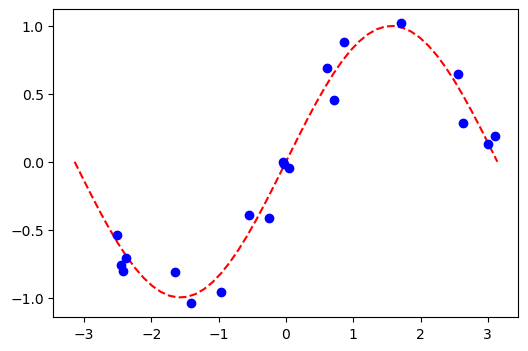

In [51]:
num_samples = 20
eps = 0.2
lb, ub = -np.pi, np.pi
print(lb,ub)
X_ = np.linspace(lb, ub, num=50).reshape(50, 1)
#print(X)
f = lambda x: np.sin(x)
#print(f)
#print(algorithm_globals.random.random([num_samples, 1])*(ub-lb)+lb)
X = (ub - lb) * algorithm_globals.random.random([num_samples, 1]) + lb
print(X)
y = f(X[:, 0]) + eps * (2 * algorithm_globals.random.random(num_samples) - 1)
print(y)
plt.plot(X_, f(X_), "r--")
plt.plot(X, y, "bo")
plt.show()

In [38]:
# construct simple feature map
param_x = Parameter("x")
feature_map = QuantumCircuit(1, name="fm")
feature_map.ry(param_x, 0)
print(feature_map)
print(feature_map.ry(param_x, 0))
# construct simple ansatz
param_y = Parameter("y")
ansatz = QuantumCircuit(1, name="vf")
ansatz.ry(param_y, 0)
print(ansatz)
print(ansatz.ry(param_y, 0))
# construct a circuit
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)

# construct QNN
regression_estimator_qnn = EstimatorQNN(circuit=qc)

   ┌───────┐
q: ┤ Ry(x) ├
   └───────┘
   ┌───────┐
q: ┤ Ry(y) ├
   └───────┘


In [39]:
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [40]:
num_iter=int(input("How many times you want to iterate ="))

How many times you want to iterate = 200


In [41]:
# construct the regressor from the neural network
regressor = NeuralNetworkRegressor(
    neural_network=regression_estimator_qnn,
    loss="squared_error",
    optimizer=L_BFGS_B(maxiter=num_iter),
    callback=callback_graph,
  
)
print(regressor.callback)


<function callback_graph at 0x00000152526D0AE0>


In [42]:
print(X)
print(len(X))
print(y)
print(len(y))

[[-1.41522950e+00]
 [ 2.60707243e+00]
 [ 2.99314407e+00]
 [-4.64448147e-01]
 [-2.68601432e+00]
 [ 9.12430043e-01]
 [ 1.73361935e+00]
 [ 1.43847009e+00]
 [-7.44517751e-01]
 [ 1.49986315e+00]
 [ 1.20123516e+00]
 [-4.22179437e-04]
 [-1.51140463e+00]
 [-4.50971398e-02]
 [ 2.38132499e+00]
 [ 1.90675966e-01]
 [-6.17187740e-01]
 [-1.34762781e+00]
 [ 1.94400571e+00]
 [ 1.14350344e+00]]
20
[-0.97252001  0.45914115  0.31545597 -0.47581636 -0.62750602  0.64429164
  1.0708002   1.12785853 -0.71585734  0.83154824  0.87479814  0.17398068
 -1.12519932  0.04713451  0.53377084  0.18946342 -0.74860786 -1.05944815
  0.99672167  1.04640247]
20


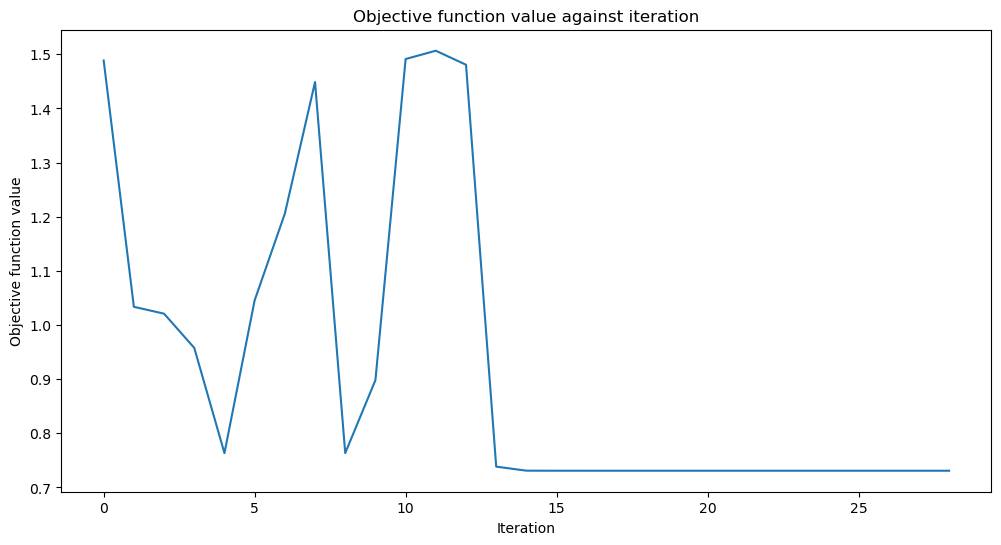

Training time: 20 seconds
regressor_score= -0.24544231954769935


In [43]:
import time
# create empty array for the callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
regressor.fit(X, y)# fit to data
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score the result
regressor_score=regressor.score(X, y)
print("regressor_score=",regressor_score)

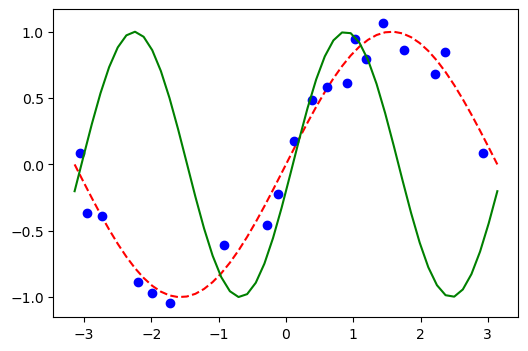

In [45]:
# plot target function
plt.plot(X_, f(X_), "r--")

# plot data
plt.plot(X, y, "bo")

# plot fitted line
y_ = regressor.predict(X_)
plt.plot(X_, y_, "g-")
plt.show()